# Load & Tiền xử lý dữ liệu

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("accepted_2007_to_2018Q4.csv", low_memory=False)

df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]
df['default'] = df['loan_status'].apply(lambda x: 1 if x=='Charged Off' else 0)

if df['int_rate'].dtype != object:
    df['int_rate'] = df['int_rate'].astype(str)

df['int_rate'] = (
    df['int_rate']
    .str.replace("%", "", regex=False)
    .str.strip()
    .replace("", np.nan)
    .astype(float)
)

df['term'] = (
    df['term']
    .astype(str)
    .str.replace(" months", "", regex=False)
    .astype(int)
)

df['annual_inc'] = df['annual_inc'].replace(0, np.nan)
df = df[df['annual_inc'].notnull()]

df['dti'] = df['dti'].replace(0, np.nan)
df = df[df['dti'].notnull()]


# Boxplot: Lãi suất theo Loan Status

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10096\3888884291.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="loan_status", y="int_rate", palette="Set2")


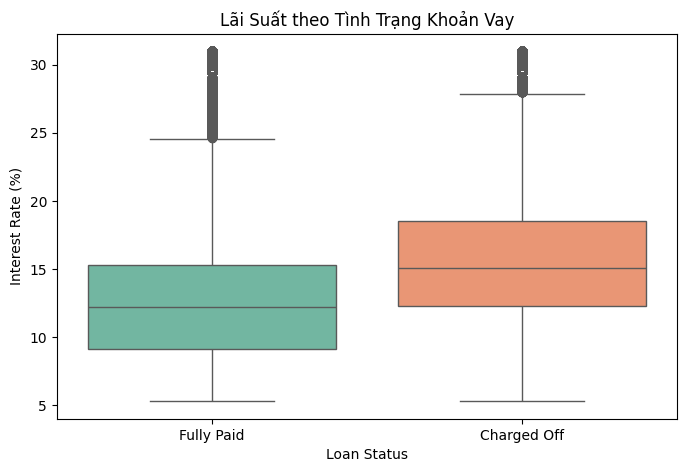

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="loan_status", y="int_rate", palette="Set2")
plt.title("Lãi Suất theo Tình Trạng Khoản Vay")
plt.xlabel("Loan Status")
plt.ylabel("Interest Rate (%)")
plt.show()


# Bar Chart: Default Rate theo Grade

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10096\2994658469.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=default_by_grade, x="grade", y="default", palette="coolwarm")


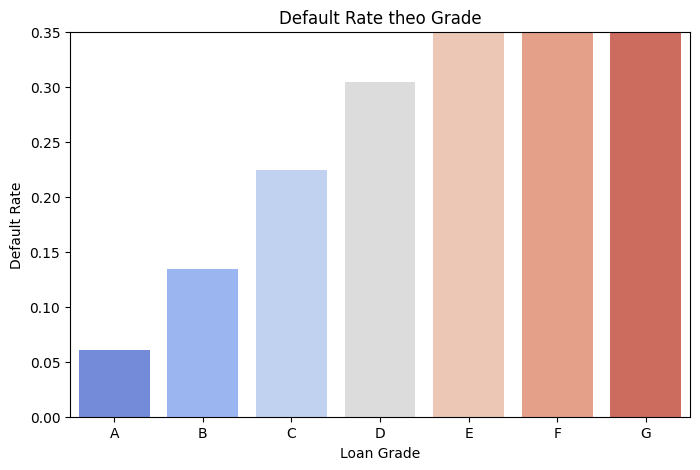

In [21]:
default_by_grade = df.groupby("grade")["default"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=default_by_grade, x="grade", y="default", palette="coolwarm")
plt.title("Default Rate theo Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Default Rate")
plt.ylim(0, 0.35)
plt.show()


# Heatmap: Grade vs Purpose (Default Rate)

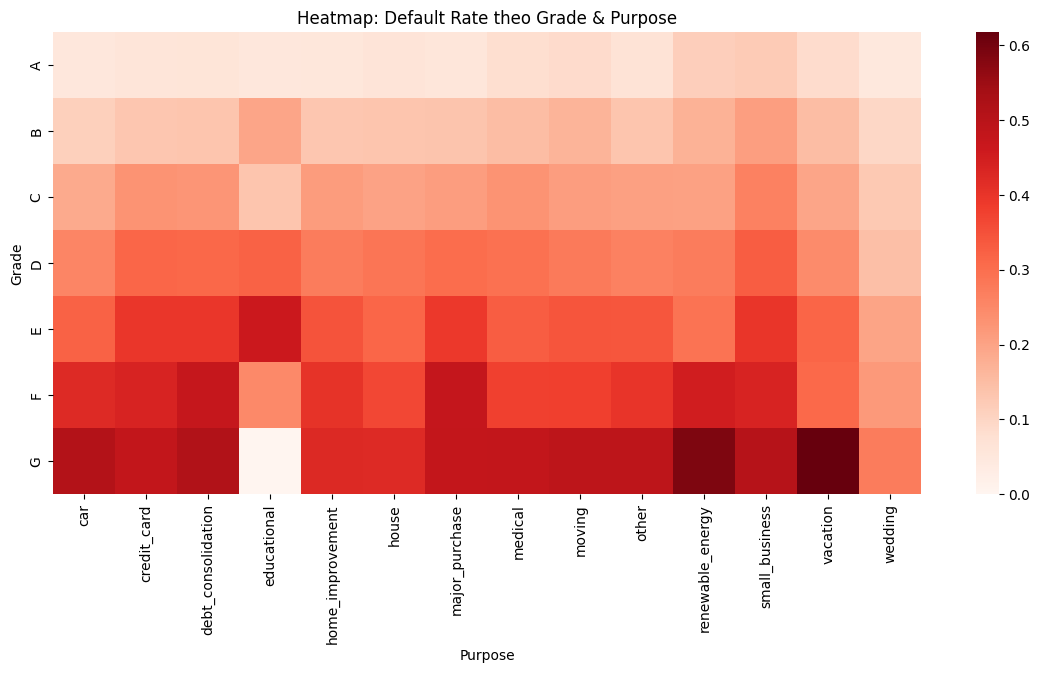

In [22]:
heatmap_data = df.pivot_table(
    values="default",
    index="grade",
    columns="purpose",
    aggfunc="mean"
)

plt.figure(figsize=(14,6))
sns.heatmap(heatmap_data, cmap="Reds", annot=False)
plt.title("Heatmap: Default Rate theo Grade & Purpose")
plt.xlabel("Purpose")
plt.ylabel("Grade")
plt.show()


# Bar Chart: Default Rate theo Purpose

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10096\464240216.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=default_by_purpose, x="purpose", y="default", palette="viridis")


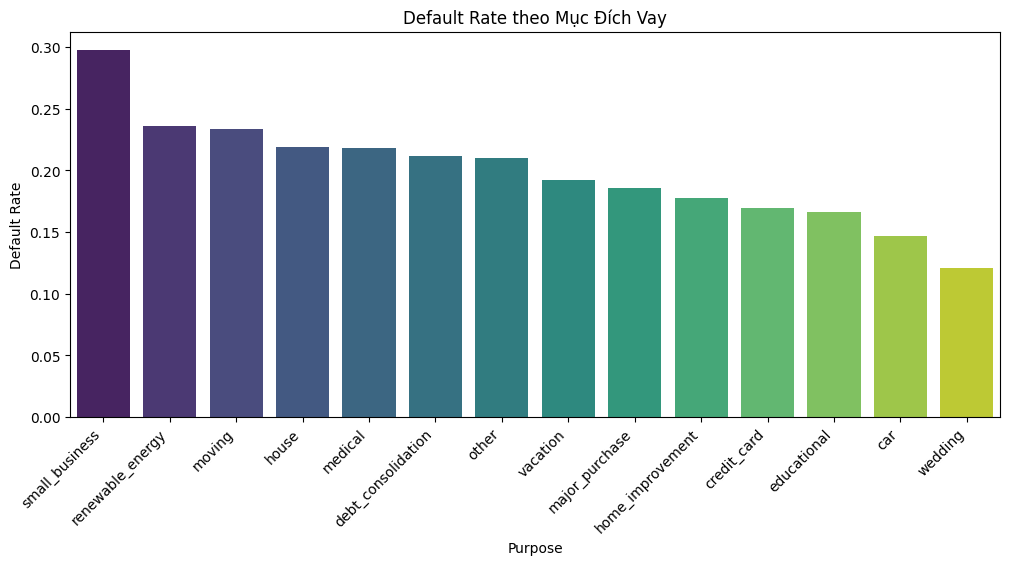

In [23]:
default_by_purpose = df.groupby("purpose")["default"].mean().reset_index().sort_values("default", ascending=False)

plt.figure(figsize=(12,5))
sns.barplot(data=default_by_purpose, x="purpose", y="default", palette="viridis")
plt.xticks(rotation=45, ha='right')
plt.title("Default Rate theo Mục Đích Vay")
plt.xlabel("Purpose")
plt.ylabel("Default Rate")
plt.show()


# Histogram: Phân bố Thu Nhập

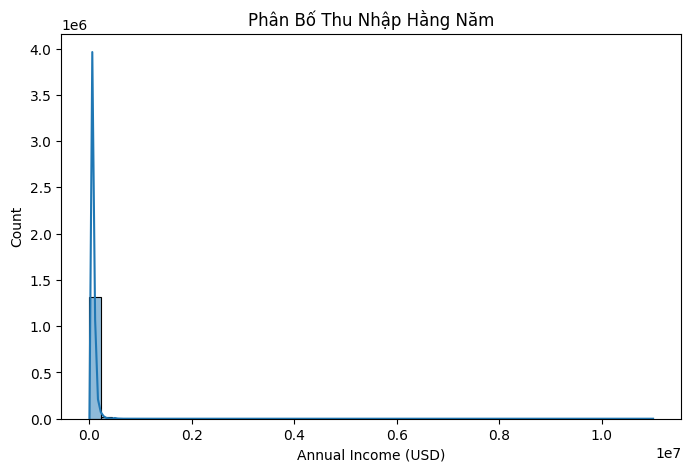

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df["annual_inc"], bins=50, kde=True)
plt.title("Phân Bố Thu Nhập Hằng Năm")
plt.xlabel("Annual Income (USD)")
plt.show()


# Bar Chart: Default Rate theo Nhóm Thu Nhập

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10096\4074476988.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_by_income = df.groupby("income_group")["default"].mean().reset_index()
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10096\4074476988.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=default_by_income, x="income_group", y="default", palette="magma")


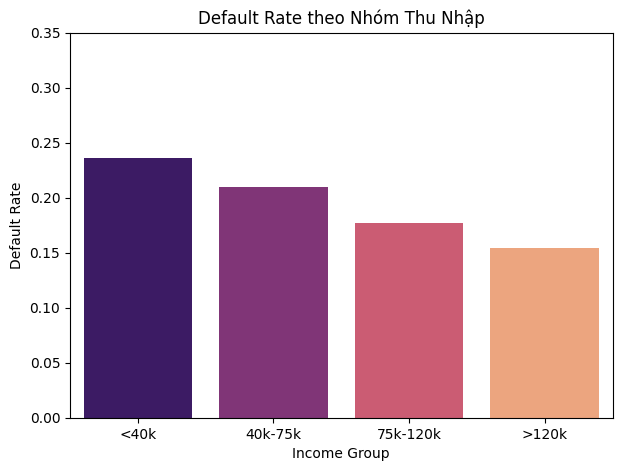

In [25]:
bins = [0, 40000, 75000, 120000, 300000]
labels = ["<40k", "40k-75k", "75k-120k", ">120k"]

df["income_group"] = pd.cut(df["annual_inc"], bins=bins, labels=labels)

default_by_income = df.groupby("income_group")["default"].mean().reset_index()

plt.figure(figsize=(7,5))
sns.barplot(data=default_by_income, x="income_group", y="default", palette="magma")
plt.title("Default Rate theo Nhóm Thu Nhập")
plt.xlabel("Income Group")
plt.ylabel("Default Rate")
plt.ylim(0, 0.35)
plt.show()


# Scatter Plot: DTI vs Interest Rate

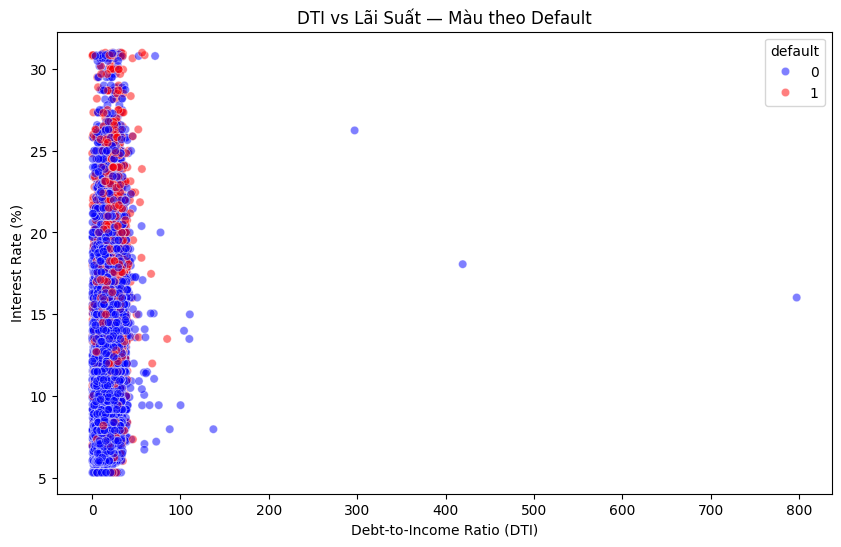

In [26]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df.sample(20000),  # giảm số điểm để dễ nhìn
    x="dti",
    y="int_rate",
    hue="default",
    alpha=0.5,
    palette={0: "blue", 1: "red"}
)
plt.title("DTI vs Lãi Suất — Màu theo Default")
plt.xlabel("Debt-to-Income Ratio (DTI)")
plt.ylabel("Interest Rate (%)")
plt.show()


# Bar Chart: Default Rate theo Term (36 vs 60 tháng)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10096\1128566104.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=default_by_term, x="term", y="default", palette="coolwarm")


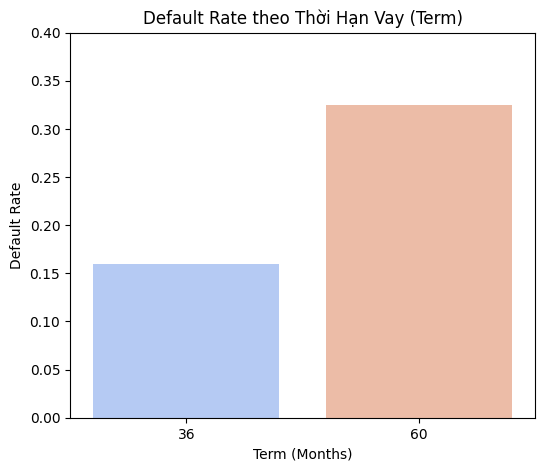

In [27]:
default_by_term = df.groupby("term")["default"].mean().reset_index()

plt.figure(figsize=(6,5))
sns.barplot(data=default_by_term, x="term", y="default", palette="coolwarm")
plt.title("Default Rate theo Thời Hạn Vay (Term)")
plt.xlabel("Term (Months)")
plt.ylabel("Default Rate")
plt.ylim(0, 0.4)
plt.show()


Các biến bị loại bỏ do tương quan cao với nhau: {'funded_amnt_inv', 'installment', 'loan_amnt', 'fico_range_high'}
Các biến còn lại sau khi loại bỏ: ['funded_amnt', 'int_rate', 'dti', 'annual_inc', 'delinq_2yrs', 'open_acc', 'pub_rec', 'total_acc', 'fico_range_low', 'acc_now_delinq', 'default_flag']


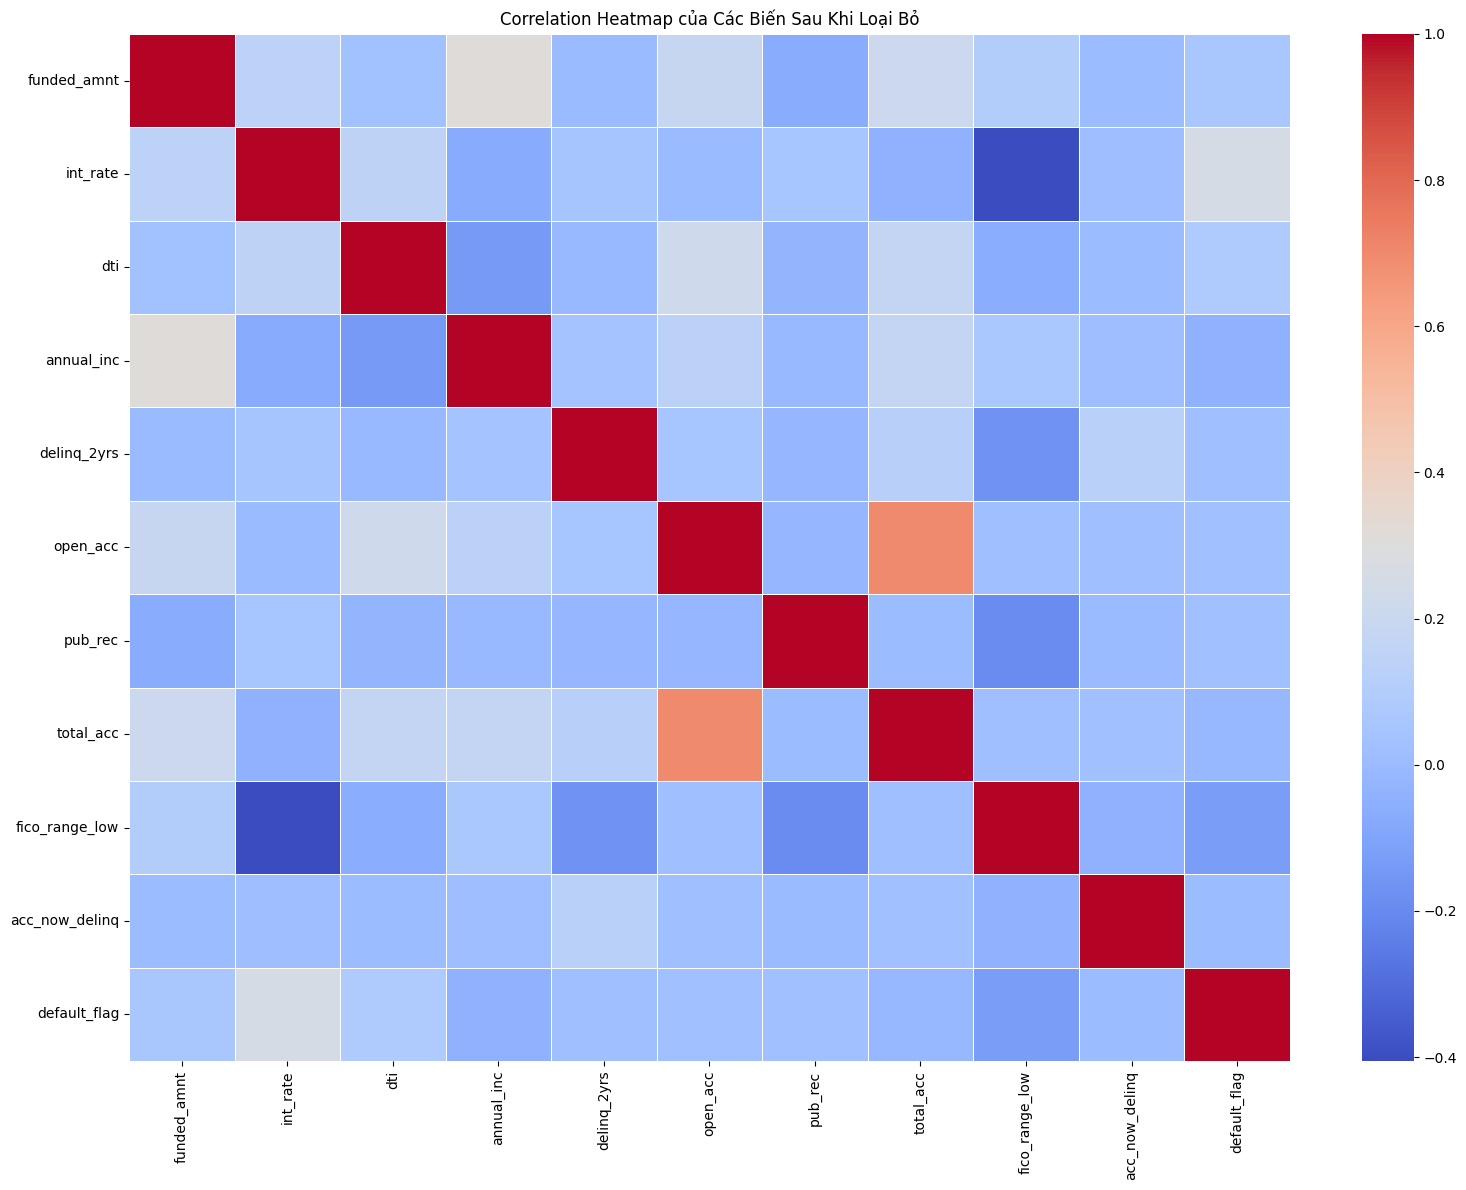

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ----------- LOAD DATA -------------
df = pd.read_csv("accepted_2007_to_2018Q4.csv", low_memory=False)

# ----------- CHỌN KHOẢN VAY ĐÃ HOÀN THÀNH -------------
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]

# ----------- CHỌN CÁC BIẾN NUMERIC ĐẦU VÀO -------------
numeric_cols = [
    "loan_amnt",        # Số tiền vay
    "funded_amnt",      # Số tiền được giải ngân
    "funded_amnt_inv",  # Số tiền đầu tư vào khoản vay
    "term",             # Thời hạn vay (có thể encode số)
    "int_rate",         # Lãi suất
    "installment",      # Khoản trả hàng tháng
    "dti",              # Debt-to-Income ratio
    "annual_inc",       # Thu nhập hàng năm
    "delinq_2yrs",      # Số lần trễ hạn 2 năm
    "open_acc",         # Số tài khoản tín dụng mở
    "pub_rec",          # Record xấu công khai
    "total_acc",        # Tổng số tài khoản
    "fico_range_low",   # FICO thấp
    "fico_range_high",  # FICO cao
    "acc_now_delinq",   # Số tài khoản hiện đang trễ hạn
    "initial_list_status"  # Mã danh sách (cần encode)
]

df = df[numeric_cols + ['loan_status']]

# ----------- TẠO NHÃN -------------
df['default_flag'] = df['loan_status'].apply(lambda x: 1 if x == 'Charged Off' else 0)

# ----------- CHỌN CÁC BIẾN NUMERIC -------------
numeric_df = df.select_dtypes(include=[np.number])
target_col = 'default_flag'

# ----------- LOẠI BỎ BIẾN TƯƠNG QUAN CAO -------------
corr_with_target = numeric_df.corr()[target_col].abs()
corr_matrix = numeric_df.corr().abs()
threshold = 0.8
to_drop = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > threshold:
            col_i = corr_matrix.columns[i]
            col_j = corr_matrix.columns[j]
            if corr_with_target[col_i] > corr_with_target[col_j]:
                to_drop.add(col_j)
            else:
                to_drop.add(col_i)

print("Các biến bị loại bỏ do tương quan cao với nhau:", to_drop)

numeric_df_filtered = numeric_df.drop(columns=to_drop)
print("Các biến còn lại sau khi loại bỏ:", list(numeric_df_filtered.columns))

# ----------- VẼ HEATMAP CÁC BIẾN FILTERED -------------
plt.figure(figsize=(16, 12))
sns.heatmap(numeric_df_filtered.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap của Các Biến Sau Khi Loại Bỏ")
plt.tight_layout()
plt.show()


c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [12:23:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy trên test set: 0.8016
ROC-AUC trên test set: 0.7055


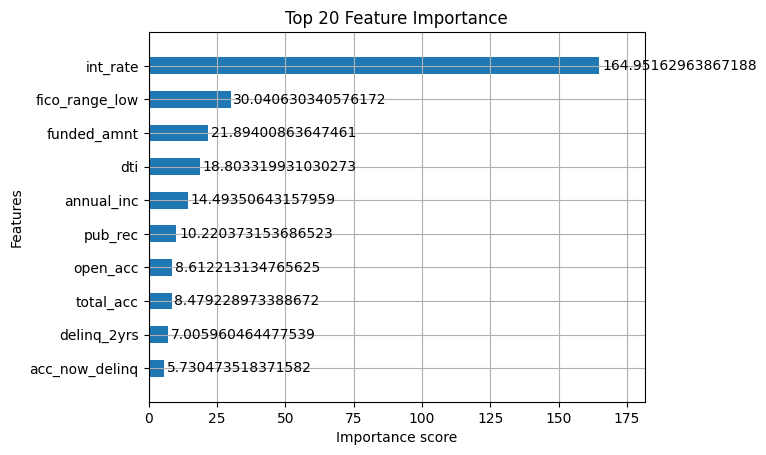

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
import xgboost as xgb

X = numeric_df.drop(columns=to_drop.union({target_col}))
y = numeric_df[target_col]

# ----------- XỬ LÝ MISSING VALUES -------------
# Đơn giản nhất: điền median
X = X.fillna(X.median())

# ----------- CHIA TRAIN/TEST -------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ----------- TRAIN XGBOOST -------------
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='auc'
)

model.fit(X_train, y_train)

# ----------- ĐÁNH GIÁ MÔ HÌNH -------------
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:,1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy trên test set: {accuracy:.4f}")
print(f"ROC-AUC trên test set: {roc_auc:.4f}")

# ----------- FEATURE IMPORTANCE -------------
import matplotlib.pyplot as plt

xgb.plot_importance(model, max_num_features=20, importance_type='gain', height=0.5)
plt.title("Top 20 Feature Importance")
plt.show()

c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [12:28:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Top 10 feature quan trọng nhất: ['int_rate', 'fico_range_low', 'funded_amnt', 'dti', 'annual_inc', 'pub_rec', 'open_acc', 'total_acc', 'delinq_2yrs', 'acc_now_delinq']


c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [12:28:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Chọn threshold để Recall ~0.7: 0.32
Threshold: 0.32
Accuracy: 0.6172
F1-score: 0.4220
Precision: 0.3021
Recall: 0.7000
ROC-AUC: 0.7059


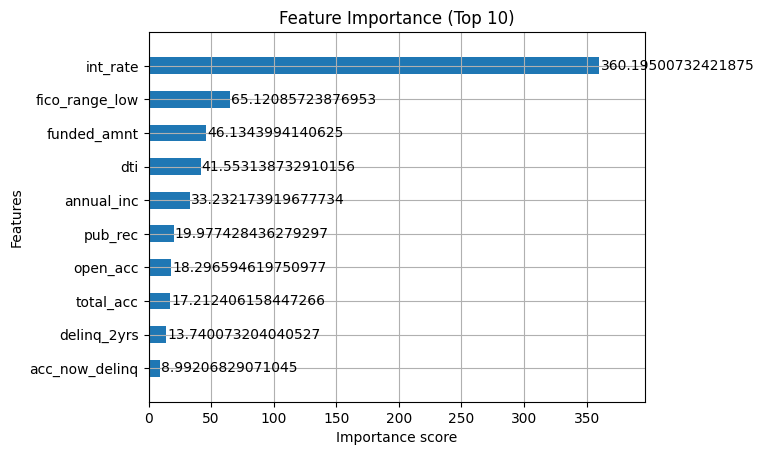

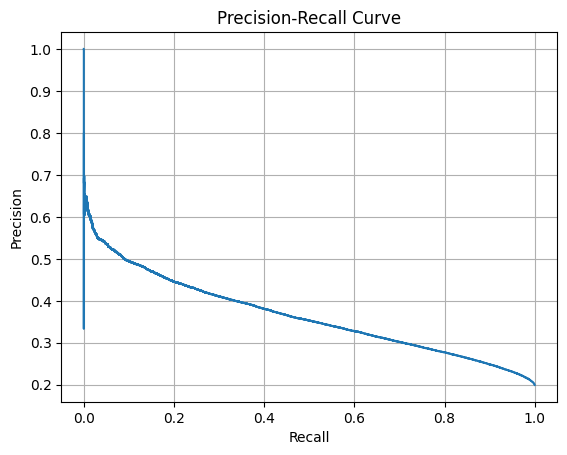

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, precision_recall_curve
)
import xgboost as xgb
import matplotlib.pyplot as plt

# ----------- CHUẨN BỊ DỮ LIỆU -------------
X = numeric_df.drop(columns=to_drop.union({target_col}))
y = numeric_df[target_col]

# Điền median cho missing values
X = X.fillna(X.median())

# Chia train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ----------- TRAIN XGBOOST TRÊN TẤT CẢ CÁC BIẾN -------------
model_all = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='auc',
    scale_pos_weight=0.5 * (y_train == 0).sum() / (y_train == 1).sum()  # giảm bias class 1
)

model_all.fit(X_train, y_train)

# ----------- LẤY TOP 10 FEATURE QUAN TRỌNG NHẤT -------------
feature_importances = model_all.get_booster().get_score(importance_type='gain')
fi_df = pd.DataFrame({
    'feature': list(feature_importances.keys()),
    'importance': list(feature_importances.values())
}).sort_values(by='importance', ascending=False)

top_features = fi_df['feature'].head(10).tolist()
print("Top 10 feature quan trọng nhất:", top_features)

# ----------- TRAIN LẠI CHỈ VỚI TOP 10 FEATURE -------------
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

model_top = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='auc',
    scale_pos_weight=0.5 * (y_train == 0).sum() / (y_train == 1).sum()
)

model_top.fit(X_train_top, y_train)

# ----------- DỰ ĐOÁN PROBA -------------
y_pred_proba = model_top.predict_proba(X_test_top)[:, 1]

# ----------- TỰ ĐỘNG CHỌN THRESHOLD CÂN BẰNG RECALL ~0.7 -------------
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_pred_proba)
target_recall = 0.7
best_idx = np.argmin(np.abs(recall_vals - target_recall))
best_threshold = thresholds[best_idx]
print(f"Chọn threshold để Recall ~{target_recall}: {best_threshold:.2f}")

y_pred_balanced = (y_pred_proba >= best_threshold).astype(int)

# ----------- ĐÁNH GIÁ MODEL -------------
accuracy = accuracy_score(y_test, y_pred_balanced)
f1 = f1_score(y_test, y_pred_balanced)
precision = precision_score(y_test, y_pred_balanced)
recall = recall_score(y_test, y_pred_balanced)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Threshold: {best_threshold:.2f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

# ----------- VẼ FEATURE IMPORTANCE TOP 10 -------------
xgb.plot_importance(model_top, max_num_features=10, importance_type='gain', height=0.5)
plt.title("Feature Importance (Top 10)")
plt.show()

# ----------- VẼ PRECISION-RECALL CURVE -------------
plt.plot(recall_vals, precision_vals)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()


In [16]:
import pandas as pd
from sqlalchemy import create_engine

# Chỉ lấy các cột cần thiết
columns_needed =['int_rate', 'fico_range_low', 'funded_amnt', 'dti', 'annual_inc', 'pub_rec', 'open_acc', 'total_acc', 'delinq_2yrs', 'acc_now_delinq','default_flag']
df_subset = df[columns_needed].head(15)  # Lấy 15 bản ghi đầu tiên

# Thông tin kết nối PostgreSQL
username = 'postgres'
password = 'postgres'
host = 'localhost'
port = '5432'
database = 'loan_default_db'
table_name = 'loan_risk_features'

# Tạo engine kết nối PostgreSQL
engine = create_engine(f'postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}')

# Chèn dữ liệu vào bảng
df_subset.to_sql(table_name, engine, if_exists='append', index=False)

print("Dữ liệu đã được chèn thành công vào PostgreSQL!")


Dữ liệu đã được chèn thành công vào PostgreSQL!


In [13]:
!pip install psycopg2

  Obtaining dependency information for psycopg2 from https://files.pythonhosted.org/packages/b5/bf/635fbe5dd10ed200afbbfbe98f8602829252ca1cce81cc48fb25ed8dadc0/psycopg2-2.9.11-cp312-cp312-win_amd64.whl.metadata
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB 1.3 MB/s eta 0:00:03
   - -------------------------------------- 0.1/2.7 MB 1.4 MB/s eta 0:00:02
   ---- ----------------------------------- 0.3/2.7 MB 2.8 MB/s eta 0:00:01
   ----------- ---------------------------- 0.8/2.7 MB 5.1 MB/s eta 0:00:01
   ----------------- ---------------------- 1.2/2.7 MB 6.0 MB/s eta 0:00:01
   ------------------- -------------------- 1.4/2.7 MB 5.4 MB/s eta 0:00:01
   ---------------------------------- ----- 2.3/2.7 MB 7.8 MB/s eta 0:00:01
   ------------------------------------ --- 2.5/2.7 MB 7.2 MB/s eta 0:00:01
   ------------------------------------- -- 2.5/2.7 MB 6.7 MB/s eta 0:00:01
   ---------------------------------


[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import joblib

# Giả sử model_top5 là model XGBoost đã train với 5 feature
top5_features = ['recoveries', 'last_fico_range_high', 'last_pymnt_amnt', 'total_rec_prncp', 'total_rec_int']

# Lưu model và danh sách features
joblib.dump(model, 'model_top5.pkl')
joblib.dump(top5_features, 'top5_features.pkl')


['top5_features.pkl']

In [3]:
import pandas as pd
df = pd.read_csv("accepted_2007_to_2018Q4.csv", low_memory=False)
# Lấy ngẫu nhiên 200 bản ghi
df_sample = df.sample(n=200, random_state=42)  # random_state để kết quả tái lập (tuỳ chọn)

# Lưu ra file CSV mới
df_sample.to_csv("temp_dashboard_data.csv", index=False)

print("Đã tạo file temp_dashboard_data.csv với 200 bản ghi mẫu.")

Đã tạo file temp_dashboard_data.csv với 200 bản ghi mẫu.


In [12]:
# ==========================================
# REALISTIC SAFE CLEANING PIPELINE
# ==========================================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

print("🚀 Realistic Safe Cleaning Pipeline Initialized!")

# ==========================================
# LOAD DATA
# ==========================================

df = pd.read_csv("accepted_2007_to_2018Q4.csv", low_memory=False)
print(f"📊 Dataset loaded: {df.shape[0]:,} rows — {df.shape[1]} columns")

# ==========================================
# DTYPE CLEANING
# ==========================================

# % --> float
percent_cols = ["int_rate", "revol_util"]

for col in percent_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace("%", "")
        df[col] = pd.to_numeric(df[col], errors="coerce")

# term → number
if "term" in df.columns:
    df["term"] = df["term"].astype(str).str.extract("(\d+)").astype(float)

# emp_length
def parse_emp_len(x):
    if pd.isna(x) or x == "n/a":
        return np.nan
    if x == "< 1 year":
        return 0
    if x == "10+ years":
        return 10
    try:
        return float(x.split()[0])
    except:
        return np.nan

if "emp_length" in df.columns:
    df["emp_length"] = df["emp_length"].astype(str).apply(parse_emp_len)

# Dates
date_cols = ["issue_d", "earliest_cr_line", "last_pymnt_d", "last_credit_pull_d"]
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], format="%b-%Y", errors="coerce")

# ==========================================
# MISSING VALUE IMPUTATION (REALISTIC)
# ==========================================

# ---- 1️⃣ Numeric → median (OK, không phá phân phối)
num_cols = df.select_dtypes(include=["float64", "int64"]).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# ---- 2️⃣ Category → sample theo phân phối gốc (KHÔNG dùng mode)
obj_cols = df.select_dtypes(include=["object"]).columns

for col in obj_cols:
    if df[col].isna().sum() > 0:
        probs = df[col].value_counts(normalize=True)
        df.loc[df[col].isna(), col] = np.random.choice(
            probs.index,
            size=df[col].isna().sum(),
            p=probs.values
        )

# ==========================================
# OUTLIER HANDLING (REALISTIC)
# Winsorizing 1% - 99%
# ==========================================

def winsorize(series, lower=0.01, upper=0.99):
    lower_v = series.quantile(lower)
    upper_v = series.quantile(upper)
    return series.clip(lower_v, upper_v)

for col in num_cols:
    df[col] = winsorize(df[col], 0.01, 0.99)

# ==========================================
# FINAL CHECK
# ==========================================

print("🧽 Realistic safe cleaning completed!")
print(f"📌 FINAL SHAPE: {df.shape[0]} rows — {df.shape[1]} columns (UNCHANGED)")

# ==========================================
# SAVE OUTPUT
# ==========================================

df.to_csv("accepted_cleaned_REALISTIC.csv", index=False)
df.to_pickle("accepted_cleaned_REALISTIC.pkl")

print("💾 Saved: accepted_cleaned_REALISTIC.csv & accepted_cleaned_REALISTIC.pkl")


🚀 Realistic Safe Cleaning Pipeline Initialized!
📊 Dataset loaded: 2,260,701 rows — 151 columns
🧽 Realistic safe cleaning completed!
📌 FINAL SHAPE: 2260701 rows — 151 columns (UNCHANGED)
💾 Saved: accepted_cleaned_REALISTIC.csv & accepted_cleaned_REALISTIC.pkl


In [ ]:
import numpy as np

if "home_ownership" in df.columns:

    # Lấy index của giá trị hiếm
    mask = df["home_ownership"].isin(["ANY", "NONE", "OTHER"])
    idx = df[mask].index

    # Tạo phân phối thực tế
    n = len(idx)
    num_rent = int(n * 0.60)
    num_mort = int(n * 0.30)
    num_own = n - num_rent - num_mort   # phần còn lại

    new_values = (
        ["RENT"] * num_rent +
        ["MORTGAGE"] * num_mort +
        ["OWN"] * num_own
    )

    # Shuffle để ngẫu nhiên hơn
    np.random.shuffle(new_values)

    # Gán lại
    df.loc[idx, "home_ownership"] = new_values

    # Chuẩn hoá
    df["home_ownership"] = df["home_ownership"].astype(str).str.upper().str.strip()
df.to_csv("accepted_cleaned_REALISTIC.csv", index=False)



In [11]:
import pandas as pd

# Đường dẫn file
file1 = "accepted_2007_to_2018Q4.csv"
file2 = "accepted_cleaned_SAFE.csv"

# Load file
df1 = pd.read_csv(file1, low_memory=False)
df2 = pd.read_csv(file2, low_memory=False)

print("====== SỐ CỘT ======")
print("File 1:", df1.shape[1])
print("File 2:", df2.shape[1])

print("\n====== CỘT CHỈ CÓ Ở FILE 1 (bị xoá ở file cleaned) ======")
cols_removed = set(df1.columns) - set(df2.columns)
for c in sorted(cols_removed):
    print(c)

print("\n====== CỘT CHỈ CÓ Ở FILE 2 (được thêm vào) ======")
cols_added = set(df2.columns) - set(df1.columns)
for c in sorted(cols_added):
    print(c)

print("\n====== CỘT CHUNG ======")
cols_common = set(df1.columns).intersection(df2.columns)
print(f"Tổng: {len(cols_common)} cột")


====== SỐ CỘT ======
File 1: 151
File 2: 151

====== CỘT CHỈ CÓ Ở FILE 1 (bị xoá ở file cleaned) ======

====== CỘT CHỈ CÓ Ở FILE 2 (được thêm vào) ======

====== CỘT CHUNG ======
Tổng: 151 cột
